# Nettoyage, feature engineering et baseline — Credit Scoring

Ce notebook part des observations de l'EDA (`01_eda.ipynb`) pour nettoyer les données, créer des
variables et entraîner un premier modèle baseline.

**Règle de non-fuite de données** : on travaille uniquement sur `data/processed/train.csv`
(le split fait dans le notebook 1). Toute statistique utilisée pour nettoyer ou transformer les
données (médiane, mode, seuils de capping, scaler) est calculée **uniquement sur le train**.
Le test (`data/processed/test.csv`) n'est ni chargé ni utilisé ici — il ne servira qu'à
l'évaluation finale du modèle retenu.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay,
    average_precision_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TARGET = "SeriousDlqin2yrs"

## 0. Chargement du train

On recharge uniquement `train.csv`, tel que sauvegardé par le notebook d'EDA (index `id`).

In [2]:
train_df = pd.read_csv("../data/processed/train.csv", index_col="id")
print(train_df.shape)
train_df.head()

(120000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
id,,,,,,,,,,,
57837,0,0.114987,62,0,1841.000000,NaN,5,0,1,0,2.0
132896,0,0.008705,73,0,0.498553,3800.0,6,0,1,0,0.0
27982,0,0.214501,32,0,0.211999,3716.0,8,0,0,0,2.0
37853,0,1.000000,60,0,118.000000,NaN,5,0,0,0,0.0
103814,0,0.230493,60,0,1.017328,3000.0,10,0,1,0,0.0


## 1. Traitement des valeurs sentinelles 96/98

L'EDA a montré que `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTime60-89DaysPastDueNotWorse`
et `NumberOfTimes90DaysLate` contiennent chacune exactement les mêmes 2 valeurs à 96 et 212
valeurs à 98, sur les mêmes lignes vraisemblablement — ce ne sont pas des retards de paiement
réels mais des **codes d'erreur du système source**.

Choix : avant de les traiter comme manquantes, on garde l'information qu'une ligne était
concernée via une variable binaire `has_sentinel_delinquency` (cette anomalie de saisie pourrait
elle-même être corrélée au risque, par exemple si elle provient d'un segment de clients
particulier). On remplace ensuite 96/98 par `NaN` puis on impute par la **médiane du train**
(peu sensible aux valeurs extrêmes restantes, contrairement à la moyenne).

In [3]:
late_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

# Variable binaire : la ligne contient-elle une valeur sentinelle sur au moins une des 3 colonnes ?
train_df["has_sentinel_delinquency"] = train_df[late_cols].isin([96, 98]).any(axis=1).astype(int)
print("Lignes concernées :", train_df["has_sentinel_delinquency"].sum())

# Remplacement des sentinelles par NaN, puis imputation par la médiane du train
for col in late_cols:
    train_df.loc[train_df[col].isin([96, 98]), col] = np.nan
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)
    print(f"{col}: médiane utilisée pour l'imputation = {median_val}")

Lignes concernées : 214
NumberOfTime30-59DaysPastDueNotWorse: médiane utilisée pour l'imputation = 0.0
NumberOfTime60-89DaysPastDueNotWorse: médiane utilisée pour l'imputation = 0.0
NumberOfTimes90DaysLate: médiane utilisée pour l'imputation = 0.0


## 2. Valeurs manquantes restantes

- `MonthlyIncome` (~19,7 % de manquants) : imputation par la médiane du train. On ajoute
  `income_was_missing` car l'absence de revenu déclaré peut elle-même être un signal de risque
  (client sans emploi stable, par exemple), pas juste un trou aléatoire dans les données.
- `NumberOfDependents` (~2,6 % de manquants) : imputation par le **mode** (variable de comptage
  à faible cardinalité, dont la valeur la plus fréquente est plus représentative qu'une médiane
  arrondie). On ajoute de même `dependents_was_missing`.

In [4]:
# MonthlyIncome
train_df["income_was_missing"] = train_df["MonthlyIncome"].isna().astype(int)
income_median = train_df["MonthlyIncome"].median()
train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(income_median)
print("Médiane MonthlyIncome utilisée :", income_median)

# NumberOfDependents
train_df["dependents_was_missing"] = train_df["NumberOfDependents"].isna().astype(int)
dependents_mode = train_df["NumberOfDependents"].mode()[0]
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(dependents_mode)
print("Mode NumberOfDependents utilisé :", dependents_mode)

Médiane MonthlyIncome utilisée : 5390.0
Mode NumberOfDependents utilisé : 0.0


In [5]:
# Vérification : il ne doit plus rester aucun NaN
missing_after = train_df.isna().sum()
assert missing_after.sum() == 0, "Il reste des valeurs manquantes !"
print("Aucune valeur manquante restante.")
missing_after

Aucune valeur manquante restante.


SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
has_sentinel_delinquency                0
income_was_missing                      0
dependents_was_missing                  0
dtype: int64

## 3. Traitement des outliers

On documente chaque anomalie et le traitement choisi plutôt que de supprimer des lignes sans
justification (supprimer des défauts, même rares, appauvrirait encore plus la classe
minoritaire).

In [6]:
# --- age ---
n_age_zero = (train_df["age"] <= 0).sum()
print("Clients avec age <= 0 :", n_age_zero)
print("age min/max avant traitement :", train_df["age"].min(), "/", train_df["age"].max())

Clients avec age <= 0 : 1
age min/max avant traitement : 0 / 109


**age** : un âge de 0 est impossible (erreur de saisie), mais ne concerne qu'un nombre très
faible de lignes. Contrairement aux sentinelles 96/98, rien n'indique que cette erreur soit
systématique ou porteuse d'information — on la traite donc comme une valeur manquante classique,
imputée par la médiane du train, sans variable binaire dédiée.

In [7]:
if n_age_zero > 0:
    train_df.loc[train_df["age"] <= 0, "age"] = np.nan
    age_median = train_df["age"].median()
    train_df["age"] = train_df["age"].fillna(age_median)
    print("age=0 remplacé par la médiane :", age_median)
else:
    print("Aucune valeur d'age aberrante détectée sur ce split.")

age=0 remplacé par la médiane : 52.0


**DebtRatio** et **RevolvingUtilizationOfUnsecuredLines** : l'EDA a montré des valeurs
extrêmes largement supérieures à ce qui est plausible (`DebtRatio` jusqu'à plusieurs centaines
de milliers, alors qu'un ratio dette/revenu au-delà de quelques unités n'a déjà plus de sens
métier ; `RevolvingUtilizationOfUnsecuredLines` jusqu'à plusieurs dizaines de milliers, alors que
ce taux d'utilisation devrait rester proche de 0-1, avec un léger dépassement possible en cas de
dépassement de découvert).

Plutôt qu'un seuil arbitraire, on **cape au 99e percentile du train** (winsorisation) : cela
limite l'influence des valeurs extrêmes sur le modèle (en particulier la régression logistique,
sensible aux outliers) sans supprimer de lignes, tout en gardant une variable binaire
`*_extreme` pour ne pas perdre l'information qu'une valeur était anormalement élevée avant
capping.

In [8]:
for col, flag_name in [
    ("DebtRatio", "debtratio_extreme"),
    ("RevolvingUtilizationOfUnsecuredLines", "revolving_extreme"),
]:
    cap = train_df[col].quantile(0.99)
    train_df[flag_name] = (train_df[col] > cap).astype(int)
    n_capped = train_df[flag_name].sum()
    train_df[col] = train_df[col].clip(upper=cap)
    print(f"{col}: seuil (p99) = {cap:.2f} | {n_capped} valeurs capées")

DebtRatio: seuil (p99) = 4977.00 | 1199 valeurs capées
RevolvingUtilizationOfUnsecuredLines: seuil (p99) = 1.09 | 1200 valeurs capées


## 4. Feature engineering

Cinq nouvelles variables, chacune justifiée par un raisonnement métier (pas juste technique) :

1. **`total_delinquency`** = somme des 3 compteurs de retards. L'EDA a montré que ces trois
   variables sont très fortement corrélées entre elles (0,98-0,99) : elles portent en grande
   partie la même information ("historique de retards de paiement"). Un total agrégé résume ce
   signal en une seule variable plus robuste, moins redondante.
2. **`income_per_dependent`** = revenu mensuel / (nombre de personnes à charge + 1). Un même
   revenu ne représente pas le même reste à vivre selon la taille du foyer à charge ; le `+1`
   représente le client lui-même et évite une division par zéro.
3. **`age_group`** = tranche d'âge (moins de 30 / 30-40 / 40-50 / 50-60 / 60 et plus). La
   relation entre âge et risque de défaut n'est pas forcément linéaire (jeunes actifs vs
   retraités), un bucketing permet à un modèle linéaire de capter des effets par tranche.
4. **`has_real_estate_loan`** = 1 si le client a au moins un prêt immobilier. Posséder un bien
   immobilier financé est souvent associé à une situation financière plus stable et à un
   engagement de long terme, donc potentiellement à un risque de défaut différent.
5. **`total_credit_lines`** = nombre de lignes de crédit ouvertes + nombre de prêts immobiliers.
   Mesure l'exposition totale au crédit du client, au-delà du seul taux d'utilisation renouvelable
   : un client avec beaucoup de lignes ouvertes peut être plus fragile financièrement même si
   chaque ligne prise isolément semble raisonnable.

In [9]:
# 1. Total des retards de paiement
train_df["total_delinquency"] = train_df[late_cols].sum(axis=1)

# 2. Revenu par personne à charge (+1 pour inclure le client lui-même, évite la division par 0)
train_df["income_per_dependent"] = train_df["MonthlyIncome"] / (train_df["NumberOfDependents"] + 1)

# 3. Tranche d'âge
age_bins = [0, 30, 40, 50, 60, 200]
age_labels = ["<30", "30-40", "40-50", "50-60", "60+"]
train_df["age_group"] = pd.cut(train_df["age"], bins=age_bins, labels=age_labels, right=False)

# 4. Possède un prêt immobilier
train_df["has_real_estate_loan"] = (train_df["NumberRealEstateLoansOrLines"] > 0).astype(int)

# 5. Exposition totale au crédit
train_df["total_credit_lines"] = (
    train_df["NumberOfOpenCreditLinesAndLoans"] + train_df["NumberRealEstateLoansOrLines"]
)

train_df[[
    "total_delinquency", "income_per_dependent", "age_group",
    "has_real_estate_loan", "total_credit_lines",
]].head()

,total_delinquency,income_per_dependent,age_group,has_real_estate_loan,total_credit_lines
id,,,,,
57837,0.0,1796.666667,60+,1,6
132896,0.0,3800.000000,60+,1,7
27982,0.0,1238.666667,30-40,0,8
37853,0.0,5390.000000,60+,0,5
103814,0.0,3000.000000,60+,1,11


## 5. Préparation pour la modélisation

- Séparation `X` / `y`.
- Encodage one-hot de `age_group` (variable catégorielle).
- Standardisation des variables **continues** uniquement (les indicatrices binaires 0/1 n'ont pas
  besoin d'être mises à l'échelle) avec un `StandardScaler` **fit sur le train uniquement**.
- Sauvegarde du scaler et de la liste des features dans `models/`, et du jeu de données transformé
  dans `data/processed/`, pour pouvoir réutiliser exactement le même pipeline sur le test plus
  tard sans réajuster quoi que ce soit dessus.

In [10]:
y_train = train_df[TARGET].copy()

# Encodage one-hot de la tranche d'âge (drop_first pour éviter la colinéarité parfaite)
age_dummies = pd.get_dummies(train_df["age_group"], prefix="age_group", drop_first=True)

continuous_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents",
    "total_delinquency",
    "income_per_dependent",
    "total_credit_lines",
]

binary_cols = [
    "has_sentinel_delinquency",
    "income_was_missing",
    "dependents_was_missing",
    "debtratio_extreme",
    "revolving_extreme",
    "has_real_estate_loan",
]

X_train = pd.concat([train_df[continuous_cols], train_df[binary_cols], age_dummies], axis=1)
print(X_train.shape)
X_train.head()

(120000, 23)


,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,total_delinquency,income_per_dependent,total_credit_lines,has_sentinel_delinquency,income_was_missing,dependents_was_missing,debtratio_extreme,revolving_extreme,has_real_estate_loan,age_group_30-40,age_group_40-50,age_group_50-60,age_group_60+
id,,,,,,,,,,,,,,,,,,,,,,,
57837,0.114987,62.0,1841.000000,5390.0,5,0.0,0.0,1,0.0,2.0,0.0,1796.666667,6,0,1,0,0,0,1,False,False,False,True
132896,0.008705,73.0,0.498553,3800.0,6,0.0,0.0,1,0.0,0.0,0.0,3800.000000,7,0,0,0,0,0,1,False,False,False,True
27982,0.214501,32.0,0.211999,3716.0,8,0.0,0.0,0,0.0,2.0,0.0,1238.666667,8,0,0,0,0,0,0,True,False,False,False
37853,1.000000,60.0,118.000000,5390.0,5,0.0,0.0,0,0.0,0.0,0.0,5390.000000,5,0,1,0,0,0,0,False,False,False,True
103814,0.230493,60.0,1.017328,3000.0,10,0.0,0.0,1,0.0,0.0,0.0,3000.000000,11,0,0,0,0,0,1,False,False,False,True


In [11]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])

X_train_scaled.describe().loc[["mean", "std"], continuous_cols].round(2)

,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,total_delinquency,income_per_dependent,total_credit_lines
mean,-0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [12]:
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(scaler, "../models/scaler.joblib")
joblib.dump(
    {"continuous_cols": continuous_cols, "binary_cols": binary_cols, "feature_names": list(X_train_scaled.columns)},
    "../models/feature_list.joblib",
)

X_train_scaled.to_csv("../data/processed/X_train_processed.csv")
y_train.to_csv("../data/processed/y_train.csv")

print("Scaler, liste de features et jeux de données sauvegardés.")

Scaler, liste de features et jeux de données sauvegardés.


## 6. Modèles baseline

Deux baselines, évaluées par **validation croisée stratifiée à 5 folds** (pour conserver ~6,68 %
de défauts dans chaque fold) :

- **Baseline 1 — DummyClassifier** (classe majoritaire) : plancher de référence.
- **Baseline 2 — Régression logistique** avec `class_weight="balanced"` : compense le
  déséquilibre de classes en pondérant davantage les erreurs sur la classe minoritaire (défaut),
  sans avoir besoin de sur/sous-échantillonner les données.

Métriques suivies : **AUC-PR** (principale, cf. README), AUC-ROC, recall et precision sur la
classe défaut (1).

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
}

models = {
    "Dummy (classe majoritaire)": DummyClassifier(strategy="most_frequent"),
    "Régression logistique (balanced)": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    ),
}

results = {}
for name, model in models.items():
    cv_results = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring=scoring)
    results[name] = {
        metric: (cv_results[f"test_{metric}"].mean(), cv_results[f"test_{metric}"].std())
        for metric in scoring
    }

results_df = pd.DataFrame(
    {name: {metric: f"{mean:.3f} (+/- {std:.3f})" for metric, (mean, std) in metrics.items()}
     for name, metrics in results.items()}
).T
results_df

C:\Users\hamza\Desktop\projet 1 ml\credit-scoring\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hamza\Desktop\projet 1 ml\credit-scoring\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hamza\Desktop\projet 1 ml\credit-scoring\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

,average_precision,roc_auc,recall,precision
Dummy (classe majoritaire),0.067 (+/- 0.000),0.500 (+/- 0.000),0.000 (+/- 0.000),0.000 (+/- 0.000)
Régression logistique (balanced),0.383 (+/- 0.007),0.857 (+/- 0.004),0.741 (+/- 0.010),0.217 (+/- 0.001)


### Matrice de confusion et courbe précision-rappel (régression logistique)

Calculées avec `cross_val_predict` (prédictions out-of-fold sur tout le train, donc toujours sans
fuite de données : chaque prédiction est faite par un modèle qui n'a pas vu cette ligne pendant
son entraînement).

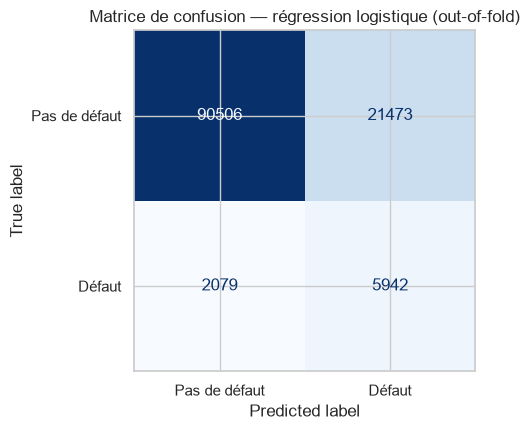

In [14]:
logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)

y_pred = cross_val_predict(logreg, X_train_scaled, y_train, cv=cv, method="predict")
y_proba = cross_val_predict(logreg, X_train_scaled, y_train, cv=cv, method="predict_proba")[:, 1]

cm = confusion_matrix(y_train, y_pred)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["Pas de défaut", "Défaut"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matrice de confusion — régression logistique (out-of-fold)")
plt.tight_layout()
plt.show()

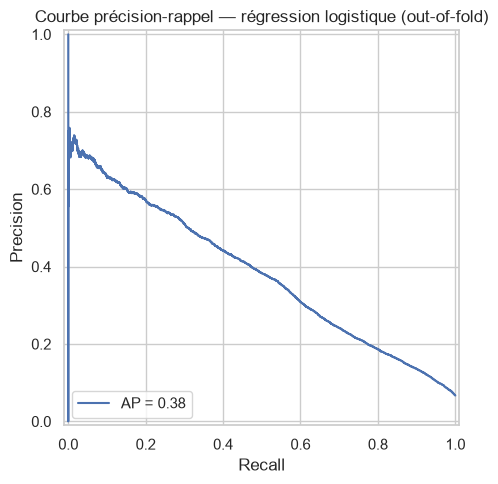

In [15]:
precision, recall, thresholds = precision_recall_curve(y_train, y_proba)
ap_score = average_precision_score(y_train, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=ap_score).plot(ax=ax)
ax.set_title("Courbe précision-rappel — régression logistique (out-of-fold)")
plt.tight_layout()
plt.show()

### Conclusion :
